In [2]:
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
LW=load_wine()
df_wine=pd.DataFrame(LW.data,columns=LW.feature_names)
df_wine['class']=LW.target
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# Histograma

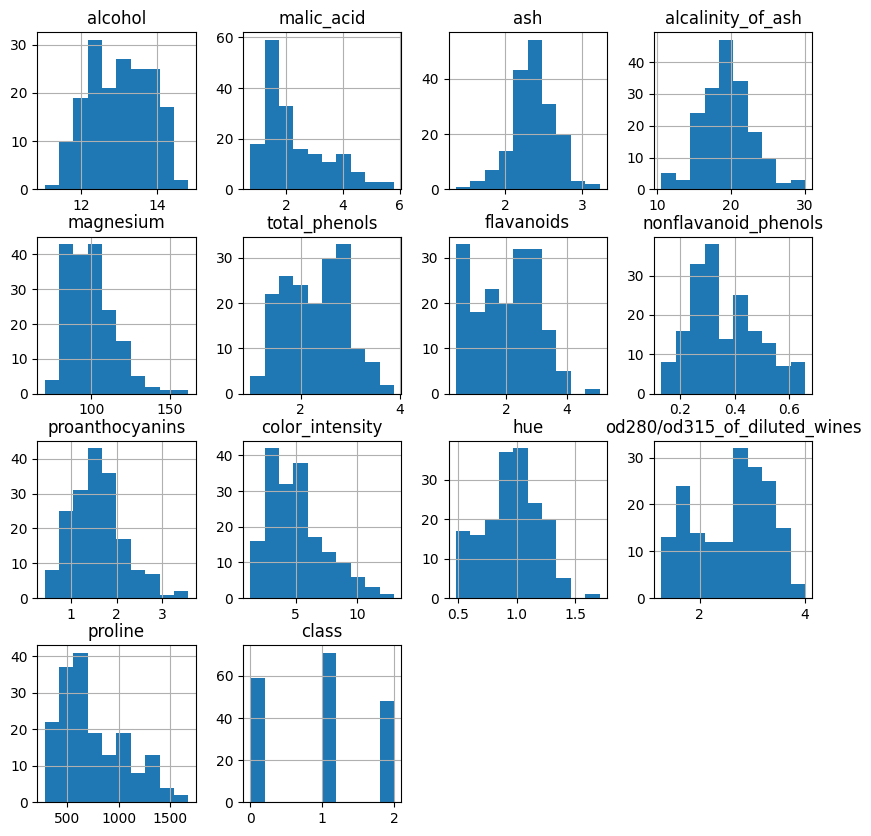

In [4]:
h=df_wine.hist(figsize=(10,10))

<Axes: >

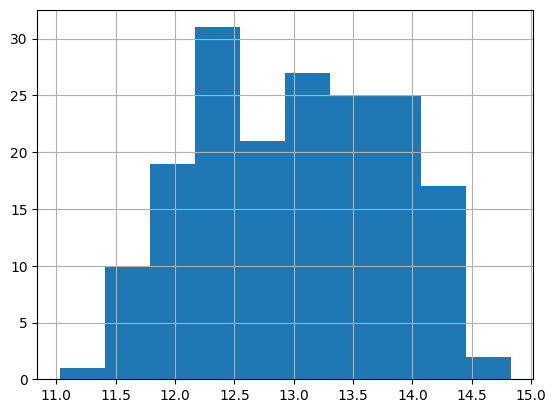

In [5]:
df_wine.alcohol.hist() # df_wine['alcohol'].hist()

(array([ 1., 10., 19., 31., 21., 27., 25., 25., 17.,  2.]),
 array([11.03, 11.41, 11.79, 12.17, 12.55, 12.93, 13.31, 13.69, 14.07,
        14.45, 14.83]),
 <BarContainer object of 10 artists>)

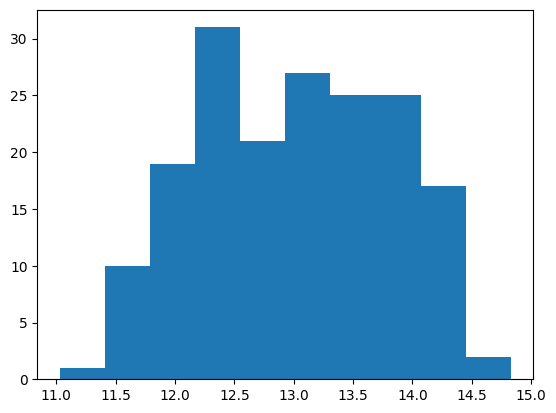

In [6]:
plt.hist(df_wine['alcohol']) # Regresa una tupla donde el primer elemento son dos arreglos: 1. Cantidad de observaciones, e 2. Intervalo de los contenedores

# Medidas de posición

In [7]:
#@title Media aritmética
df_wine.mean()

,0
alcohol,13.000618
malic_acid,2.336348
ash,2.366517
alcalinity_of_ash,19.494944
magnesium,99.741573
total_phenols,2.295112
flavanoids,2.029270
nonflavanoid_phenols,0.361854
proanthocyanins,1.590899
color_intensity,5.058090


In [8]:
df_wine.alcohol.mean()

np.float64(13.00061797752809)

In [9]:
import numpy as np

In [10]:
np.mean(df_wine.alcohol)

np.float64(13.00061797752809)

In [11]:
np.mean(df_wine,axis=0) # Hacemos la suma por renglones

,0
alcohol,13.000618
malic_acid,2.336348
ash,2.366517
alcalinity_of_ash,19.494944
magnesium,99.741573
total_phenols,2.295112
flavanoids,2.029270
nonflavanoid_phenols,0.361854
proanthocyanins,1.590899
color_intensity,5.058090


In [12]:
#@title Media recortada
from scipy import stats

<Axes: >

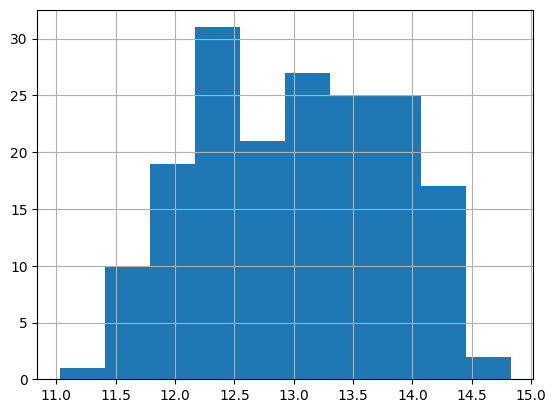

In [13]:
df_wine.alcohol.hist()

In [14]:
stats.trim_mean(df_wine.alcohol,0.1) # Corte simétrico del 10%

np.float64(13.006388888888889)

In [15]:
stats.tmean(df_wine.alcohol,(11.5,14.5))

np.float64(13.018488372093024)

In [16]:
# Media recortada para todas las variables
stats.trim_mean(df_wine,0.1) # De forma predeterminada axis=0

array([1.30063889e+01, 2.21152778e+00, 2.37375000e+00, 1.94194444e+01,
       9.84444444e+01, 2.28576389e+00, 2.02020833e+00, 3.55069444e-01,
       1.56409722e+00, 4.82770833e+00, 9.58583333e-01, 2.63118056e+00,
       7.19298611e+02, 9.23611111e-01])

In [17]:
#@title Media ponderada
#
# Necesitamos saber de qué tamaño es la observación
df_wine.alcohol.shape

(178,)

In [18]:
W=np.ones(df_wine.alcohol.shape)
W[0:2]=2 # A los primeros dos elementos les asignamos un peso de 2
W

array([2., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1.])

In [19]:
np.average(df_wine.alcohol,weights=W)

np.float64(13.008555555555555)

In [20]:
#@title Media geométrica y armónica
stats.gmean(df_wine.alcohol) # Media geométrica

np.float64(12.975278352602606)

In [21]:
stats.gmean(df_wine)

array([1.29752784e+01, 2.10655027e+00, 2.35006078e+00, 1.92047930e+01,
       9.87945076e+01, 2.20614882e+00, 1.72633531e+00, 3.40592502e-01,
       1.48269582e+00, 4.56323347e+00, 9.28760027e-01, 2.50412397e+00,
       6.85605753e+02, 0.00000000e+00])

In [22]:
stats.hmean(df_wine.alcohol) # Media armónica

np.float64(12.949820740397147)

In [23]:
# La media geométrica es mayor a la media armónica
stats.gmean(df_wine.drop(columns='class'))-stats.hmean(df_wine.drop(columns='class'))

array([2.54576122e-02, 1.92524772e-01, 1.73739811e-02, 3.00961376e-01,
       8.88846079e-01, 9.18967047e-02, 3.33277240e-01, 2.10323586e-02,
       1.20681233e-01, 4.56814589e-01, 3.01862458e-02, 1.16971463e-01,
       5.50556241e+01])

In [24]:
#@title Mediana
df_wine.median()

,0
alcohol,13.050
malic_acid,1.865
ash,2.360
alcalinity_of_ash,19.500
magnesium,98.000
total_phenols,2.355
flavanoids,2.135
nonflavanoid_phenols,0.340
proanthocyanins,1.555
color_intensity,4.690


In [25]:
np.median(df_wine,axis=0)

array([1.305e+01, 1.865e+00, 2.360e+00, 1.950e+01, 9.800e+01, 2.355e+00,
       2.135e+00, 3.400e-01, 1.555e+00, 4.690e+00, 9.650e-01, 2.780e+00,
       6.735e+02, 1.000e+00])

In [26]:
#@title Moda
df_wine.alcohol.mode() # Tenemos dos valores repetidos con la misma cantidad de observaciones

,alcohol
0,12.37
1,13.05


In [27]:
stats.mode(df_wine.alcohol)

ModeResult(mode=np.float64(12.37), count=np.int64(6))

In [28]:
df_wine.alcohol.mode()[0] # Extraemos simpre el primer elemento

np.float64(12.37)

In [29]:
stats.mode(df_wine.alcohol)[0] # Extraemos la moda

np.float64(12.37)

In [30]:
#@title Cuantiles
df_wine.quantile(0.1) # Cuantil-10 o Decíl

,0.1
alcohol,11.933
malic_acid,1.247
ash,2.000
alcalinity_of_ash,16.000
magnesium,85.000
total_phenols,1.471
flavanoids,0.607
nonflavanoid_phenols,0.217
proanthocyanins,0.854
color_intensity,2.549


In [31]:
df_wine.quantile([0.25,0.5,0.75]) # Cuartíles

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0.25,12.3625,1.6025,2.2100,17.2,88.0,1.7425,1.205,0.2700,1.250,3.22,0.7825,1.9375,500.5,0.0
0.50,13.0500,1.8650,2.3600,19.5,98.0,2.3550,2.135,0.3400,1.555,4.69,0.9650,2.7800,673.5,1.0
0.75,13.6775,3.0825,2.5575,21.5,107.0,2.8000,2.875,0.4375,1.950,6.20,1.1200,3.1700,985.0,2.0


In [34]:
np.quantile(df_wine,[0.25,0.5,0.75],axis=0)

array([[1.23625e+01, 1.60250e+00, 2.21000e+00, 1.72000e+01, 8.80000e+01,
        1.74250e+00, 1.20500e+00, 2.70000e-01, 1.25000e+00, 3.22000e+00,
        7.82500e-01, 1.93750e+00, 5.00500e+02, 0.00000e+00],
       [1.30500e+01, 1.86500e+00, 2.36000e+00, 1.95000e+01, 9.80000e+01,
        2.35500e+00, 2.13500e+00, 3.40000e-01, 1.55500e+00, 4.69000e+00,
        9.65000e-01, 2.78000e+00, 6.73500e+02, 1.00000e+00],
       [1.36775e+01, 3.08250e+00, 2.55750e+00, 2.15000e+01, 1.07000e+02,
        2.80000e+00, 2.87500e+00, 4.37500e-01, 1.95000e+00, 6.20000e+00,
        1.12000e+00, 3.17000e+00, 9.85000e+02, 2.00000e+00]])

# Medidas de dispersión

In [35]:
#@title Desviación estándar y varianza
df_wine.std() # Desviación estándar (muestral)

,0
alcohol,0.811827
malic_acid,1.117146
ash,0.274344
alcalinity_of_ash,3.339564
magnesium,14.282484
total_phenols,0.625851
flavanoids,0.998859
nonflavanoid_phenols,0.124453
proanthocyanins,0.572359
color_intensity,2.318286


In [36]:
df_wine.var() # Varianza (muestral)

,0
alcohol,0.659062
malic_acid,1.248015
ash,0.075265
alcalinity_of_ash,11.152686
magnesium,203.989335
total_phenols,0.391690
flavanoids,0.997719
nonflavanoid_phenols,0.015489
proanthocyanins,0.327595
color_intensity,5.374449


In [37]:
np.std(df_wine,axis=0) # Desviación estándar (poblacional)

,0
alcohol,0.809543
malic_acid,1.114004
ash,0.273572
alcalinity_of_ash,3.330170
magnesium,14.242308
total_phenols,0.624091
flavanoids,0.996049
nonflavanoid_phenols,0.124103
proanthocyanins,0.570749
color_intensity,2.311765


In [39]:
np.std(df_wine,axis=0,ddof=1) # Desviación estñandar muestral (igual a pandas)

,0
alcohol,0.811827
malic_acid,1.117146
ash,0.274344
alcalinity_of_ash,3.339564
magnesium,14.282484
total_phenols,0.625851
flavanoids,0.998859
nonflavanoid_phenols,0.124453
proanthocyanins,0.572359
color_intensity,2.318286


In [42]:
# np.std? (ddof = Delta Degree of Freedom)

In [43]:
#@title Rango
np.ptp(df_wine.alcohol) # pick to pick

np.float64(3.8000000000000007)

In [44]:
df_wine.alcohol.max()-df_wine.alcohol.min()

3.8000000000000007

In [47]:
#@title Rango intercuartílico
stats.iqr(df_wine,axis=0)

array([1.3150e+00, 1.4800e+00, 3.4750e-01, 4.3000e+00, 1.9000e+01,
       1.0575e+00, 1.6700e+00, 1.6750e-01, 7.0000e-01, 2.9800e+00,
       3.3750e-01, 1.2325e+00, 4.8450e+02, 2.0000e+00])

In [48]:
df_wine.quantile(0.75)-df_wine.quantile(0.25)

,0
alcohol,1.3150
malic_acid,1.4800
ash,0.3475
alcalinity_of_ash,4.3000
magnesium,19.0000
total_phenols,1.0575
flavanoids,1.6700
nonflavanoid_phenols,0.1675
proanthocyanins,0.7000
color_intensity,2.9800


In [49]:
#@title Coeficiente de variación (Pearson)
stats.variation(df_wine,axis=0)

array([0.06226957, 0.47681402, 0.11560124, 0.17082223, 0.14279209,
       0.27192157, 0.4908411 , 0.34296507, 0.35875872, 0.45704302,
       0.23805811, 0.27108673, 0.42043713, 0.82376147])

In [52]:
np.std(df_wine,axis=0)/np.abs(np.mean(df_wine,axis=0))

,0
alcohol,0.062270
malic_acid,0.476814
ash,0.115601
alcalinity_of_ash,0.170822
magnesium,0.142792
total_phenols,0.271922
flavanoids,0.490841
nonflavanoid_phenols,0.342965
proanthocyanins,0.358759
color_intensity,0.457043


# Medidas de forma

In [53]:
#@title Coeficiente de Fisher (asimetría)
df_wine.skew()

,0
alcohol,-0.051482
malic_acid,1.039651
ash,-0.176699
alcalinity_of_ash,0.213047
magnesium,1.098191
total_phenols,0.086639
flavanoids,0.025344
nonflavanoid_phenols,0.450151
proanthocyanins,0.517137
color_intensity,0.868585


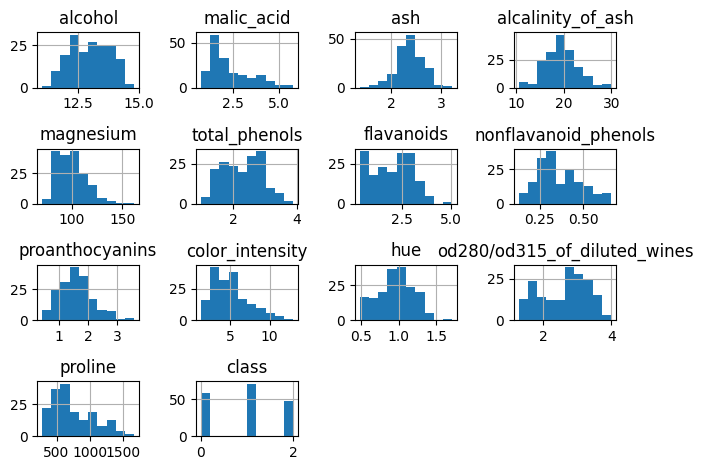

In [55]:
df_wine.hist()
plt.tight_layout()

In [56]:
#@title Curtósis
df_wine.kurt()

,0
alcohol,-0.852500
malic_acid,0.299207
ash,1.143978
alcalinity_of_ash,0.487942
magnesium,2.104991
total_phenols,-0.835627
flavanoids,-0.880382
nonflavanoid_phenols,-0.637191
proanthocyanins,0.554649
color_intensity,0.381522
